# Full Cluster Wake Map -- Nygaard vs. SuperGaussian (orange heat map)
Single-purpose notebook: build the full populated cluster (real + synthetic-fill farms), run it through a full wind rose, and render the wake map at the prevailing direction for the two literature-validated models (Nygaard 2022 and Blondel & Cathelain 2020), using an orange/hot colormap instead of viridis's yellow.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from py_wake.literature.turbopark import Nygaard_2022
from py_wake.literature.gaussian_models import Blondel_Cathelain_2020
from py_wake.turbulence_models import CrespoHernandez
from py_wake.flow_map import HorizontalGrid

from config import (
    ERA5_DIR, SITE_YEAR, FOCUS_FARM, FIGURES_DIR,
    FLOWMAP_WS_SNAPSHOT, FLOWMAP_GRID_RESOLUTION,
)
from site_builder import build_site
from cluster_layout import load_cluster
from aep_simulation import build_turbine_types, _combined_arrays, compute_neighbor_aep

plt.style.use("dark_background")
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["axes.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"

# Orange heat map instead of viridis's yellow top-end.
WAKE_MAP_CMAP = "inferno"

/opt/anaconda3/envs/Wind_2200/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Wind Rose, Full Cluster Layout
Build the reference year's site (full 12-sector Weibull wind rose from ERA5) and the fully populated cluster -- real farms plus the synthetic grid-fill for every not-yet-built lease area.

In [2]:
site, summary = build_site(ERA5_DIR / f"era5_{SITE_YEAR}.grib")
farms = load_cluster()
real_farms = [f for f in farms if not f["is_synthetic"]]
multi_turbines, type_by_farm = build_turbine_types(farms)

SIM_WD_SECTORS = list(range(0, 360, 30))
dominant_wd = SIM_WD_SECTORS[int(np.argmax(summary["freq"]))]
print(f"Reference year {SITE_YEAR}: mean speed {summary['mean_speed']:.2f} m/s, "
      f"dominant direction {dominant_wd} deg (wind rose freq={max(summary['freq']):.3f})")

_, x_full, y_full, type_full = _combined_arrays(farms, type_by_farm, FOCUS_FARM)
print(f"Full cluster: {len(x_full)} turbines across {len(farms)} farms")

Ignoring index file '/Users/brunoboer/Desktop/Advanced_Optimizer/Project_Monte_Carlo/era5_vineyard/era5_2023.grib.5b7b6.idx' incompatible with GRIB file


Reference year 2023: mean speed 8.53 m/s, dominant direction 240 deg (wind rose freq=0.153)
Full cluster: 1008 turbines across 12 farms


## 2. Two Wake Models (DTU literature wrappers)
Nygaard 2022 (TurbOPark/TurboGaussian) and Blondel & Cathelain 2020 (SuperGaussian), both built from `py_wake.literature` so the parametrization matches the benchmark papers rather than bare deficit-model defaults.

In [3]:
WFM_BUILDERS = {
    "Nygaard_TurboGaussian": lambda s, t: Nygaard_2022(s, t),
    "SuperGaussian": lambda s, t: Blondel_Cathelain_2020(s, t, turbulenceModel=CrespoHernandez()),
}

## 2b. AEP -- Vineyard Wind, Real Neighbors vs. Full Cluster
Same full wind rose (all `SIM_WD` x `SIM_WS`) used everywhere else in the pipeline -- not just the single-direction snapshot used for the flow map above.

In [4]:
aep_results = {}
for name, build_wfm in WFM_BUILDERS.items():
    wfm_m = build_wfm(site, multi_turbines)
    real_aep, *_ = compute_neighbor_aep(wfm_m, real_farms, type_by_farm, FOCUS_FARM)
    full_aep, *_ = compute_neighbor_aep(wfm_m, farms, type_by_farm, FOCUS_FARM)
    impact_pct = (real_aep - full_aep) / real_aep * 100
    aep_results[name] = dict(real_aep=real_aep, full_aep=full_aep, impact_pct=impact_pct)
    print(f"{name}: real neighbors={real_aep:.0f} GWh/yr, full cluster={full_aep:.0f} GWh/yr, "
          f"cluster impact={impact_pct:.2f}%")

Nygaard_TurboGaussian: real neighbors=2847 GWh/yr, full cluster=2391 GWh/yr, cluster impact=15.99%


SuperGaussian: real neighbors=2951 GWh/yr, full cluster=2566 GWh/yr, cluster impact=13.05%


## 3. Wake Map -- Full Cluster, Prevailing Direction
One flow-map snapshot per model, wind from the dominant direction at the reference wind speed, full cluster (real + synthetic) turbines.

In [5]:
flow_maps = {}
for name, build_wfm in WFM_BUILDERS.items():
    wfm_m = build_wfm(site, multi_turbines)
    sim_snap = wfm_m(x_full, y_full, type=type_full, wd=[dominant_wd], ws=[FLOWMAP_WS_SNAPSHOT])
    flow_maps[name] = sim_snap.flow_map(grid=HorizontalGrid(resolution=FLOWMAP_GRID_RESOLUTION))
    print(f"{name}: flow map done")

Nygaard_TurboGaussian: flow map done


SuperGaussian: flow map done


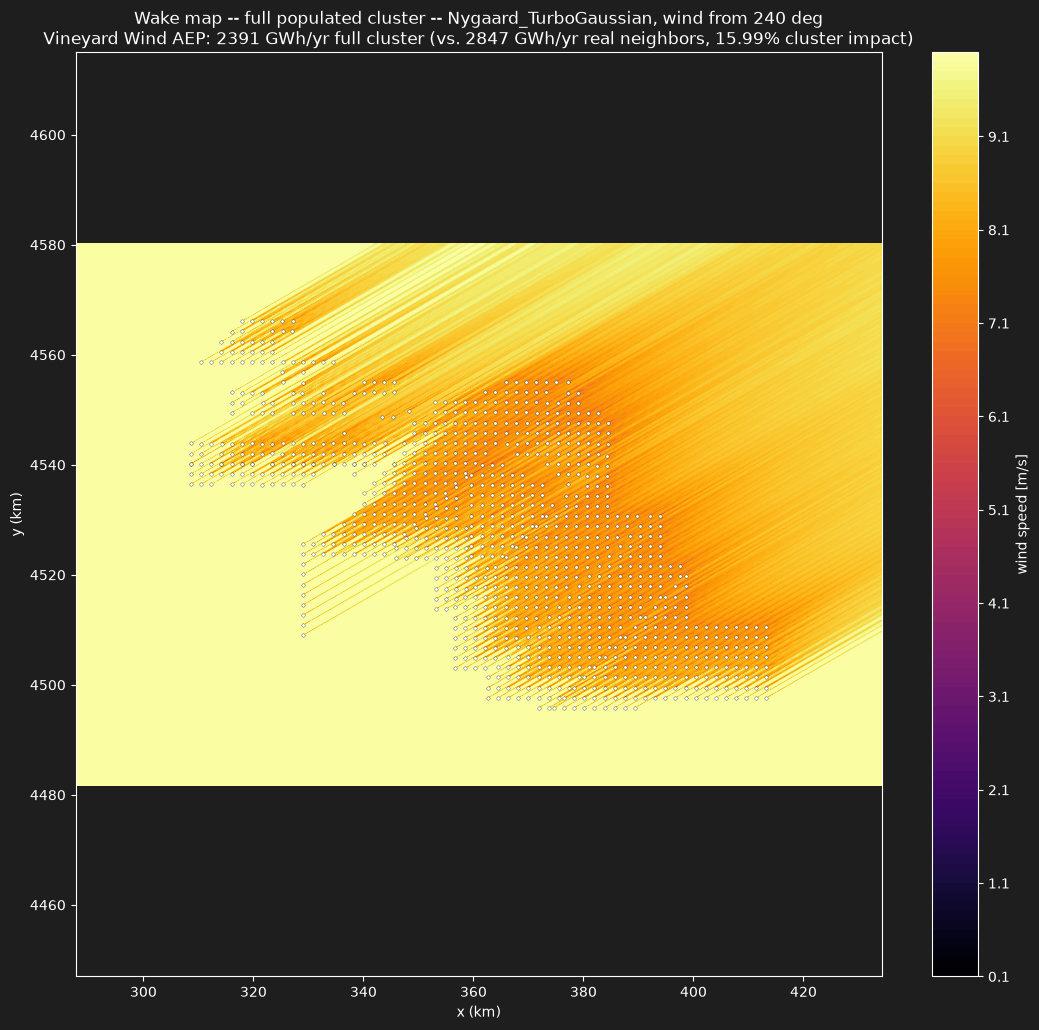

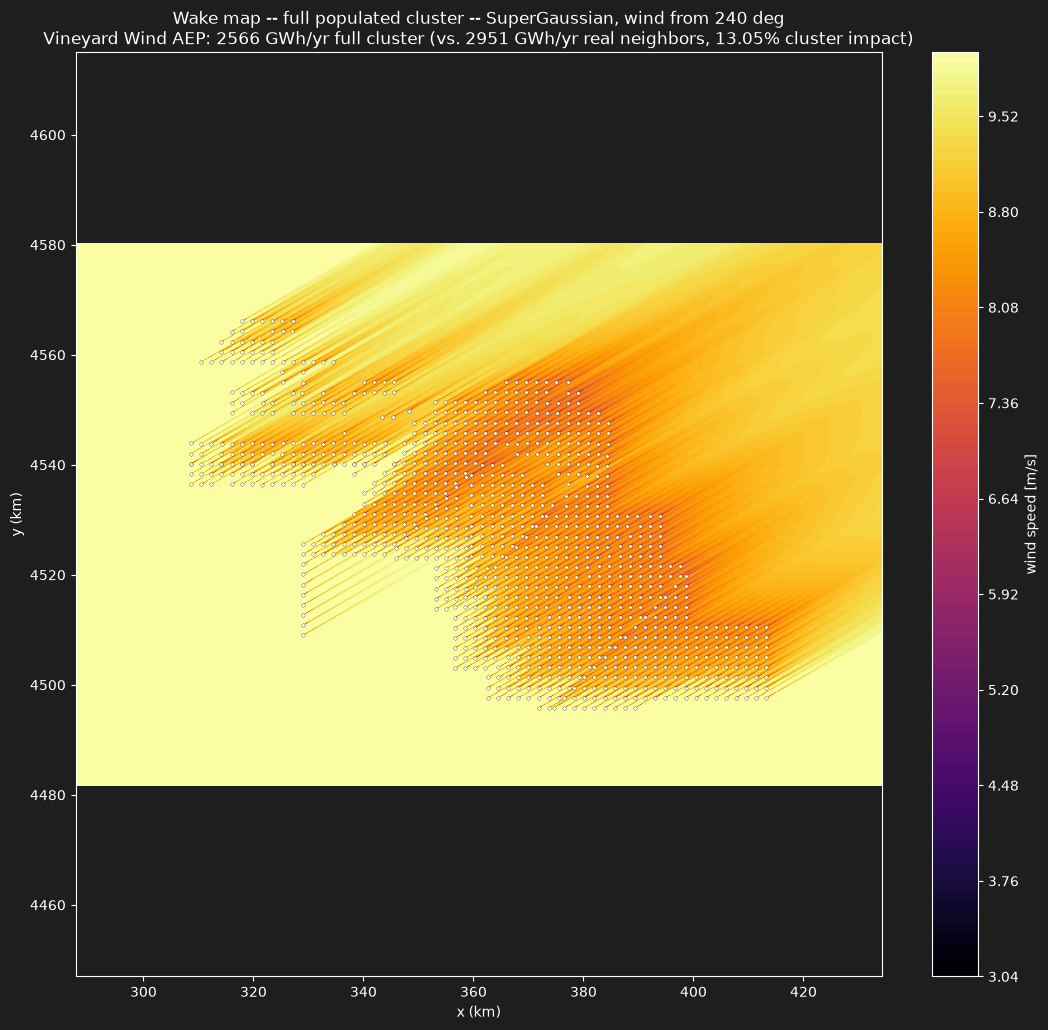

In [6]:
for name, fmap in flow_maps.items():
    r = aep_results[name]
    fig, ax = plt.subplots(figsize=(13, 12))
    fmap.plot_wake_map(ax=ax, cmap=WAKE_MAP_CMAP, normalize_with=1000, plot_windturbines=False)
    ax.scatter(np.array(x_full) / 1000, np.array(y_full) / 1000, s=6, color="white", edgecolor="black", linewidth=0.2)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(f"Wake map -- full populated cluster -- {name}, wind from {dominant_wd} deg\n"
                 f"Vineyard Wind AEP: {r['full_aep']:.0f} GWh/yr full cluster "
                 f"(vs. {r['real_aep']:.0f} GWh/yr real neighbors, {r['impact_pct']:.2f}% cluster impact)")
    fig.savefig(FIGURES_DIR / f"nb2_wake_map_full_cluster_{name.lower()}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 4. Side-by-Side Comparison

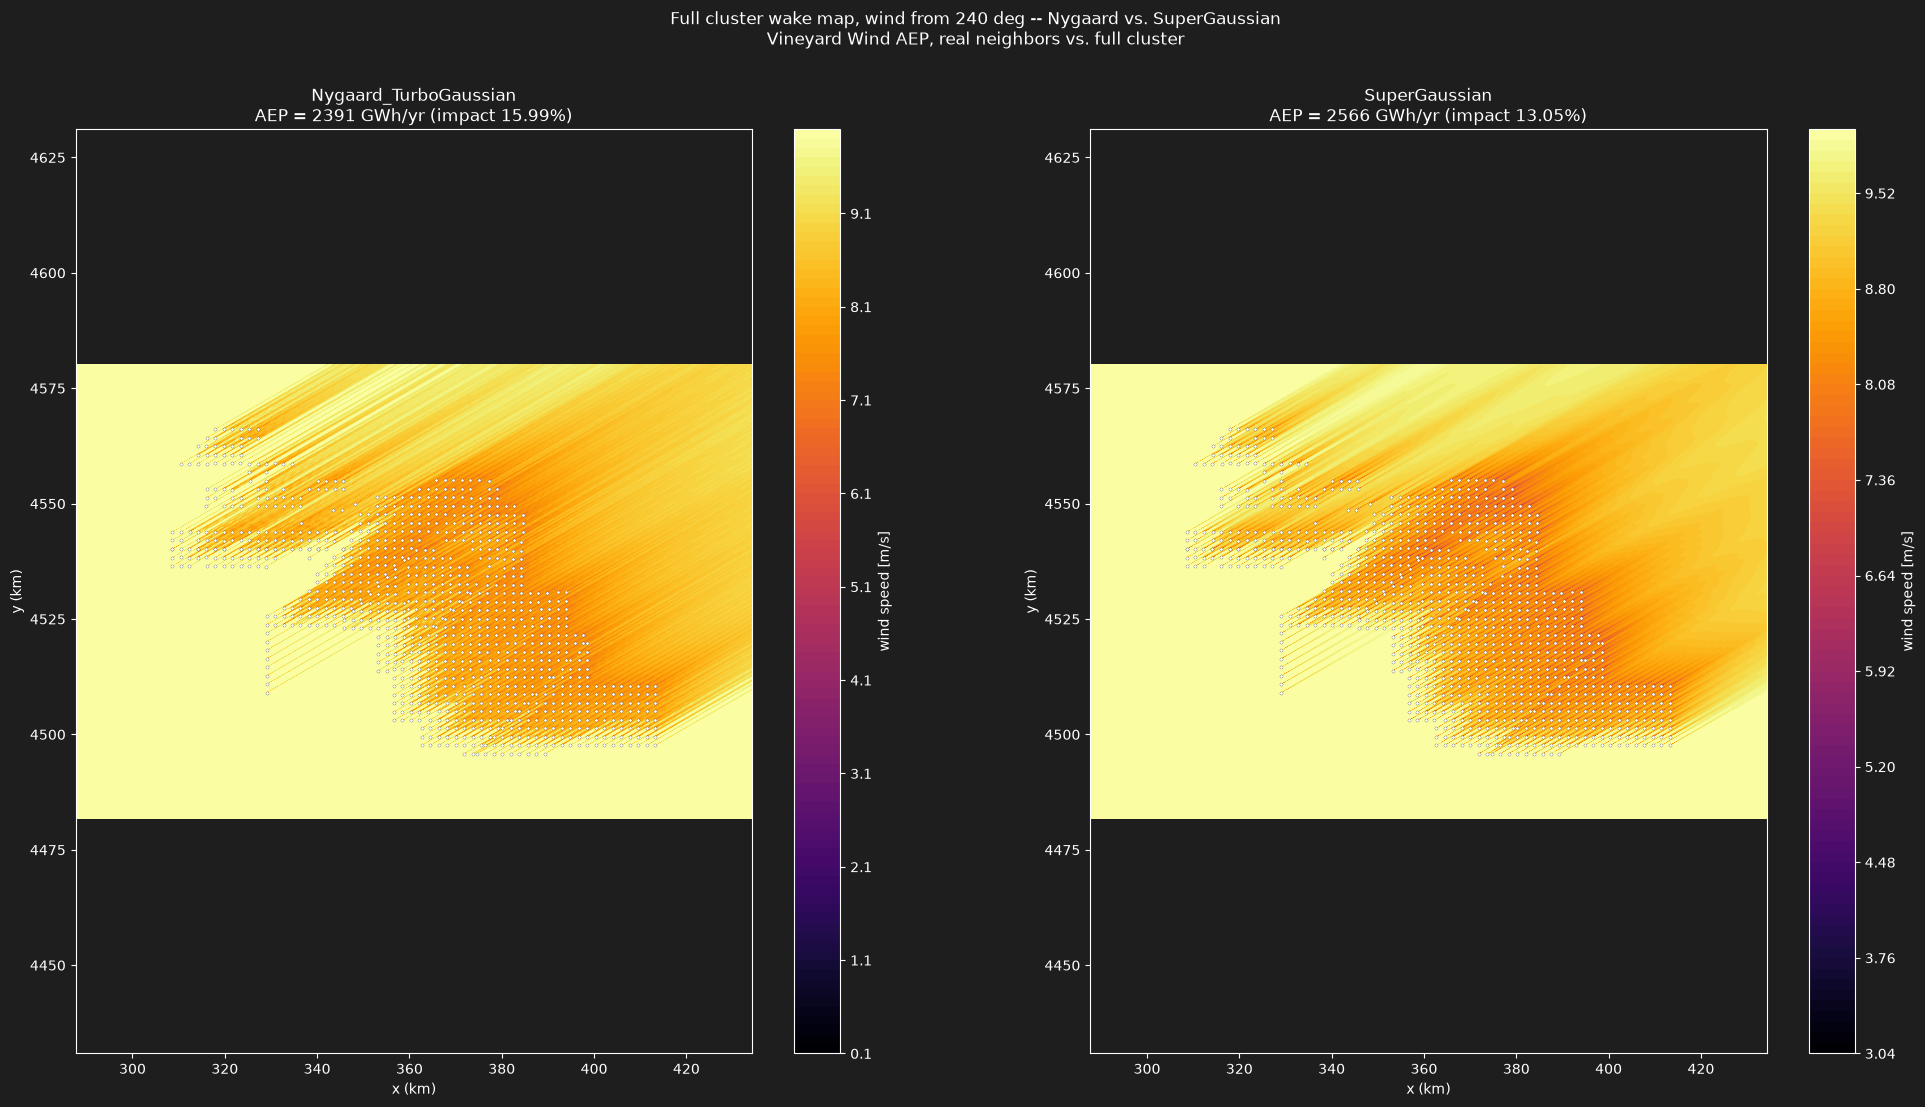

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))
for ax, (name, fmap) in zip(axes, flow_maps.items()):
    r = aep_results[name]
    fmap.plot_wake_map(ax=ax, cmap=WAKE_MAP_CMAP, normalize_with=1000, plot_windturbines=False)
    ax.scatter(np.array(x_full) / 1000, np.array(y_full) / 1000, s=5, color="white", edgecolor="black", linewidth=0.15)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(f"{name}\nAEP = {r['full_aep']:.0f} GWh/yr (impact {r['impact_pct']:.2f}%)")

fig.suptitle(f"Full cluster wake map, wind from {dominant_wd} deg -- Nygaard vs. SuperGaussian\n"
             f"Vineyard Wind AEP, real neighbors vs. full cluster")
fig.savefig(FIGURES_DIR / "nb2_wake_map_full_cluster_comparison.png", dpi=180, bbox_inches="tight")
plt.show()